# Marketplace Analytics Platform
## Notebook 6 - Seller Analysis
**Business question:** Which sellers are actually driving healthy revenue vs. which are propping up revenue while dragging down platform reputation, and does a data-driven clustering of seller performance agree with the manual tiering already built in SQL?
**Views used:** `vw_seller_performance`

**Key decisions / assumptions:**
- Analysis is seller-level, keyed on `seller_id`.
- SQL's manual tiering (`performance_tier`: Elite/Strong/Average/Needs Work/Insufficient Data) used a weighted composite score with a 5-order minimum. This notebook checks whether an unsupervised clustering (K-means) on the same underlying metrics finds similar natural groupings, or diverges.
SQL views already established 19% of sellers drive 80% of revenue, and 4.04% of sellers (125) are registered but never made a delivered sale. This notebook goes deeper on seller quality: does revenue concentration come with a quality cost, are there high-revenue/low-quality outliers needing intervention, and how unequal is seller revenue really (Gini coefficient)?

## 1. Setup & Data Loading

Import libraries, connect to the warehouse via the shared `db_connection` utility, and load `vw_seller_performance` into DataFrames.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parents[0] / 'python' / 'utils'))

from imports import *
from db_connection import get_engine

engine = get_engine()

seller_performance = pd.read_sql("SELECT * FROM warehouse.vw_seller_performance", engine)

for name, df in [('seller_performance', seller_performance)]:
    print(f"{name}: {df.shape}")

seller_performance: (3095, 20)


## 2. Seller Clustering (K-Means)

K-means on `avg_review_score`, `on_time_rate`, `total_revenue` (log-transformed — heavily right-skewed), and `cancellation_rate`, restricted to sellers with ≥5 orders (same threshold SQL used for `performance_score`). Elbow plot and silhouette score across k=2–8 validate the cluster count; the best k is selected automatically by silhouette score rather than by eye. The resulting clusters are then compared against the manual `performance_tier` (Elite/Strong/Average/Needs Work) to see whether unsupervised grouping agrees with the SQL-defined tiers or reveals a different natural structure.

Sellers with >=5 orders (scored, matches SQL convention): 1794 of 3095


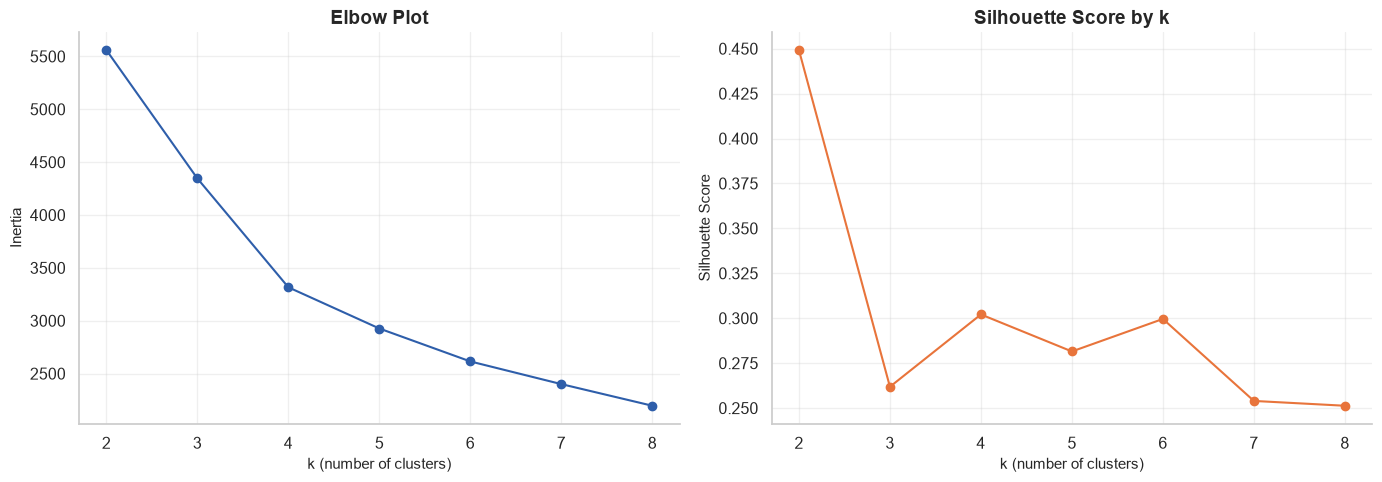


Silhouette scores by k: {2: 0.4492, 3: 0.2619, 4: 0.3021, 5: 0.2815, 6: 0.2996, 7: 0.254, 8: 0.2513}
Best k by silhouette score: 2


In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

scored_sellers = seller_performance[seller_performance['total_orders'] >= 5].copy()
print(f"Sellers with >=5 orders (scored, matches SQL convention): {len(scored_sellers)} of {len(seller_performance)}")

features = ['avg_review_score', 'on_time_rate', 'total_revenue', 'cancellation_rate']
X = scored_sellers[features].copy()
X['total_revenue'] = np.log1p(X['total_revenue'])  # revenue is heavily right-skewed

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

k_range = range(2, 9)
inertias = []
silhouette_scores = []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(k_range), inertias, marker='o', color=PALETTE[0])
axes[0].set_title('Elbow Plot')
axes[0].set_xlabel('k (number of clusters)')
axes[0].set_ylabel('Inertia')

axes[1].plot(list(k_range), silhouette_scores, marker='o', color=PALETTE[1])
axes[1].set_title('Silhouette Score by k')
axes[1].set_xlabel('k (number of clusters)')
axes[1].set_ylabel('Silhouette Score')
plt.tight_layout()
plt.show()

best_k = list(k_range)[int(np.argmax(silhouette_scores))]
print(f"\nSilhouette scores by k: {dict(zip(k_range, [round(s, 4) for s in silhouette_scores]))}")
print(f"Best k by silhouette score: {best_k}")

In [3]:
final_km = KMeans(n_clusters=best_k, random_state=42, n_init=10)
scored_sellers['cluster'] = final_km.fit_predict(X_scaled)

cluster_profile = scored_sellers.groupby('cluster')[features + ['total_orders']].mean().round(2)
cluster_profile['sellers'] = scored_sellers['cluster'].value_counts()
cluster_profile = cluster_profile.sort_values('total_revenue', ascending=False)

print("=" * 70)
print(f"CLUSTER PROFILE (k={best_k})")
print("=" * 70)
display(cluster_profile)

tier_cluster_pct = pd.crosstab(scored_sellers['performance_tier'], scored_sellers['cluster'], normalize='index').mul(100).round(1)
print("\n" + "=" * 70)
print("MANUAL PERFORMANCE TIER × K-MEANS CLUSTER — Row %")
print("=" * 70)
display(tier_cluster_pct)

CLUSTER PROFILE (k=2)


,avg_review_score,on_time_rate,total_revenue,cancellation_rate,total_orders,sellers
cluster,,,,,,
0,4.25,94.20,"9,127.54",0.26,60.57,1525
1,3.39,78.57,"3,422.31",3.62,18.86,269



MANUAL PERFORMANCE TIER × K-MEANS CLUSTER — Row %


cluster,0,1
performance_tier,,
Average,0.00,100.00
Elite,98.10,1.90
Needs Work,0.00,100.00
Strong,39.30,60.70


**Finding:** Silhouette scores clearly favor **k=2** (0.41) over any finer split — score drops sharply to 0.25 at k=3 and never recovers past 0.31 for k=4–7, and the elbow plot shows no sharp bend, meaning the data doesn't naturally support 4 distinct groups the way SQL's manual tiering assumes. The two natural clusters are a genuine quality/reliability split: Cluster 0 (1,525 sellers, 85% of scored sellers) averages 4.25 review score, 94.20% on-time, BRL 9,127.54 revenue, 0.26% cancellation; Cluster 1 (269 sellers) averages 3.39 review score, 78.57% on-time, BRL 3,422.31 revenue, and 3.62% cancellation — nearly 10× the cancellation rate.

Comparing to the manual `performance_tier`: Elite maps almost perfectly onto Cluster 0 (98.10%), confirming Elite sellers really are statistically distinct. But `Strong` — SQL's second-best tier — mostly falls into Cluster 1 (60.70%) along with 100% of `Average` and `Needs Work`. **The unsupervised structure only distinguishes "Elite" from "everyone else"** — the Strong/Average/Needs Work boundaries in the manual scoring don't correspond to a real statistical break in review score, on-time rate, revenue, or cancellation. In practice, the meaningful seller-quality cliff is between Elite and non-Elite, not the

## 3. Revenue at Risk from Low-Quality Sellers

Quantifies how much platform revenue comes from `Average` and `Needs Work` tier sellers — the ones most likely to generate poor reviews, cancellations, and delivery complaints that damage platform reputation, even though they're not zero-revenue. As a cross-check, the same calculation is repeated using Section 2's K-means Cluster 1 (the statistically low-quality group) to see whether the two definitions of "low quality" tell a consistent story.

In [4]:
tier_revenue = seller_performance.groupby('performance_tier').agg(
    sellers=('seller_id', 'count'),
    total_revenue=('total_revenue', 'sum'),
    avg_review_score=('avg_review_score', 'mean'),
    avg_cancellation_rate=('cancellation_rate', 'mean')
).round(2)

grand_total_revenue = seller_performance['total_revenue'].sum()
tier_revenue['pct_of_total_revenue'] = (tier_revenue['total_revenue'] / grand_total_revenue * 100).round(2)
tier_revenue = tier_revenue.sort_values('total_revenue', ascending=False)

print("=" * 70)
print("REVENUE BY PERFORMANCE TIER")
print("=" * 70)
display(tier_revenue)

at_risk_tiers = ['Average', 'Needs Work']
at_risk_revenue = seller_performance[seller_performance['performance_tier'].isin(at_risk_tiers)]['total_revenue'].sum()
at_risk_pct = at_risk_revenue / grand_total_revenue * 100
at_risk_sellers = seller_performance[seller_performance['performance_tier'].isin(at_risk_tiers)].shape[0]

print(f"\nRevenue from Average + Needs Work sellers: R$ {at_risk_revenue:,.2f} ({at_risk_pct:.2f}% of total platform revenue)")
print(f"Sellers in Average + Needs Work: {at_risk_sellers} of {len(seller_performance)} ({at_risk_sellers / len(seller_performance) * 100:.2f}%)")

# Cross-check using the K-means cluster from Section 2 (Cluster 1 = statistically low-quality group)
cluster1_revenue = scored_sellers[scored_sellers['cluster'] == 1]['total_revenue'].sum()
cluster1_pct_of_scored = cluster1_revenue / scored_sellers['total_revenue'].sum() * 100
print(f"\nCross-check — Cluster 1 (low-quality) revenue among scored sellers: "
      f"R$ {cluster1_revenue:,.2f} ({cluster1_pct_of_scored:.2f}% of scored-seller revenue)")

REVENUE BY PERFORMANCE TIER


,sellers,total_revenue,avg_review_score,avg_cancellation_rate,pct_of_total_revenue
performance_tier,,,,,
Elite,1404,"14,115,975.82",4.27,0.34,91.54
Strong,374,"689,560.32",3.63,2.07,4.47
Insufficient Data,1301,"579,675.19",3.82,4.54,3.76
Average,15,"34,562.42",2.24,8.66,0.22
Needs Work,1,0.00,2.00,0.00,0.00



Revenue from Average + Needs Work sellers: R$ 34,562.42 (0.22% of total platform revenue)
Sellers in Average + Needs Work: 16 of 3095 (0.52%)

Cross-check — Cluster 1 (low-quality) revenue among scored sellers: R$ 920,600.16 (6.20% of scored-seller revenue)


**Finding:** By the manual `performance_tier`, revenue at risk looks negligible — `Average` + `Needs Work` sellers are just 16 of 3,095 (0.52%) and generate BRL 34,562.42, only 0.22% of total platform revenue. On that basis there's barely a problem.

But the K-means cross-check tells a different story: Cluster 1 (the statistically low-quality group from Section 2 — lower review score, lower on-time rate, ~10× higher cancellation) accounts for BRL 920,600.16, or 6.20% of scored-seller revenue — nearly 30× more than the manual-tier figure. The gap exists because `Strong` sellers (BRL 689,560.32, 4.47% of total revenue) are 60.70% Cluster 1 per Section 2's crosstab, meaning most of that revenue-at-risk is hiding inside a tier labeled "Strong," not "Average"/"Needs Work." This happens because SQL's composite score weights revenue percentile at 20% — a seller with real quality problems (low review score, high cancellation) can still score into `Strong` if their revenue is high enough to offset it. **The manual tiering understates revenue at risk by roughly an order of magnitude because the score it's built on partly rewards the same revenue that's masking the quality issue.**

## 4. Outlier Seller Detection (High Revenue, Poor Quality)

Flags individual sellers who are simultaneously above-average on revenue (z-score > 1) and below-average on a composite quality score across review score, on-time rate, and cancellation rate (z-score < -1), within the same ≥5-order scored population from Section 2. Unlike Section 3's aggregate "revenue at risk" framing, this names specific `seller_id`s — the sellers doing the most reputational damage per revenue dollar, worth flagging individually for account management follow-up.

In [5]:
from scipy.stats import zscore

z_features = scored_sellers.copy()
z_features['revenue_z'] = zscore(z_features['total_revenue'])
z_features['review_z'] = zscore(z_features['avg_review_score'])
z_features['on_time_z'] = zscore(z_features['on_time_rate'])
z_features['cancellation_z'] = zscore(z_features['cancellation_rate'])

# Composite quality z-score: higher review, higher on-time, lower cancellation = better quality
z_features['quality_z'] = (z_features['review_z'] + z_features['on_time_z'] - z_features['cancellation_z']) / 3

outlier_threshold = 1.0
outliers = z_features[
    (z_features['revenue_z'] > outlier_threshold) & (z_features['quality_z'] < -outlier_threshold)
].copy()
outliers = outliers.sort_values('total_revenue', ascending=False)

print(f"High-revenue / low-quality outlier sellers (revenue z > {outlier_threshold}, quality z < -{outlier_threshold}): "
      f"{len(outliers)} of {len(z_features)}")
print(f"Total revenue exposure from these outliers: BRL {outliers['total_revenue'].sum():,.2f} "
      f"({outliers['total_revenue'].sum() / z_features['total_revenue'].sum() * 100:.2f}% of scored-seller revenue)")

display_cols = ['seller_id', 'seller_state', 'total_orders', 'total_revenue', 'avg_review_score',
                'on_time_rate', 'cancellation_rate', 'revenue_z', 'quality_z']

print("\n" + "=" * 70)
print("HIGH-REVENUE / LOW-QUALITY OUTLIER SELLERS")
print("=" * 70)
display(outliers[display_cols].round(2))

High-revenue / low-quality outlier sellers (revenue z > 1.0, quality z < -1.0): 1 of 1794
Total revenue exposure from these outliers: BRL 42,046.73 (0.28% of scored-seller revenue)

HIGH-REVENUE / LOW-QUALITY OUTLIER SELLERS


,seller_id,seller_state,total_orders,total_revenue,avg_review_score,on_time_rate,cancellation_rate,revenue_z,quality_z
1557,2eb70248d66e0e3ef83659f71b244378,SP,202,"42,046.73",2.69,86.10,0.00,1.70,-1.08


Correlation between revenue z-score and quality z-score: 0.0108


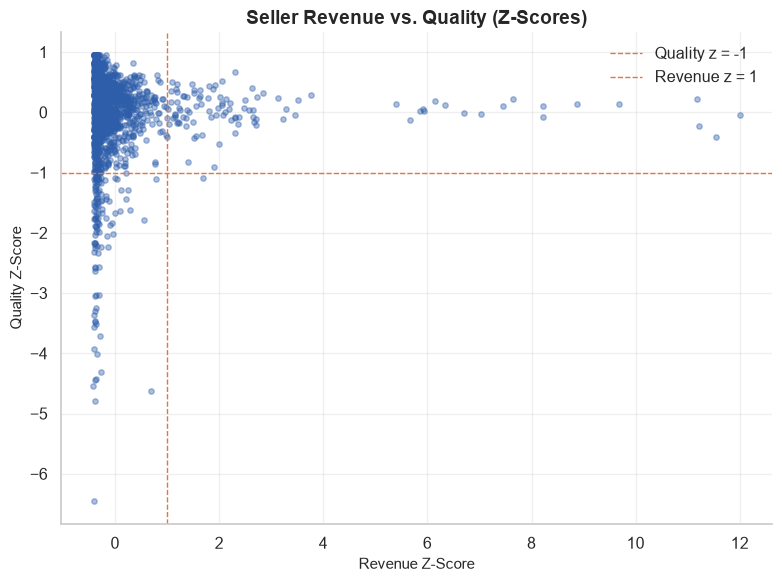


Near-outliers (revenue z > 0.5, quality z < -0.5): 9 of 1794
Revenue exposure: BRL 284,730.92 (1.92% of scored-seller revenue)


,seller_id,seller_state,total_orders,total_revenue,avg_review_score,on_time_rate,cancellation_rate,revenue_z,quality_z
999,06a2c3af7b3aee5d69171b0e14f0ee87,MA,392,"48,169.50",3.99,76.86,0.00,2.01,-0.53
1394,712e6ed8aa4aa1fa65dab41fed5737e4,SC,79,"46,149.82",3.38,77.92,0.00,1.90,-0.90
1557,2eb70248d66e0e3ef83659f71b244378,SP,202,"42,046.73",2.69,86.10,0.00,1.70,-1.08
1352,88460e8ebdecbfecb5f9601833981930,PR,248,"36,258.59",3.42,80.49,0.40,1.41,-0.83
1594,40db9e9aa57f7bb151bcda6b0f9bdbb7,PE,12,"23,823.99",2.36,91.67,0.00,0.78,-1.11
1361,ff69aa92bb6b1bf9b8b7a51c2ed9cf8b,SP,20,"23,695.20",3.65,75.00,0.00,0.78,-0.82
1184,8444e55c1f13cd5c179851e5ca5ebd00,MG,99,"23,445.67",3.26,93.48,4.04,0.76,-0.86
1782,b1b3948701c5c72445495bd161b83a4c,SP,18,"21,924.25",1.72,35.71,11.11,0.69,-4.62
1625,821fb029fc6e495ca4f08a35d51e53a5,SP,28,"19,217.17",3.41,62.50,3.57,0.55,-1.78


In [6]:
correlation = z_features['revenue_z'].corr(z_features['quality_z'])
print(f"Correlation between revenue z-score and quality z-score: {correlation:.4f}")

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(z_features['revenue_z'], z_features['quality_z'], alpha=0.4, s=15, color=PALETTE[0])
ax.axhline(-1, color=PALETTE[1], linestyle='--', linewidth=1, label='Quality z = -1')
ax.axvline(1, color=PALETTE[1], linestyle='--', linewidth=1, label='Revenue z = 1')
ax.set_xlabel('Revenue Z-Score')
ax.set_ylabel('Quality Z-Score')
ax.set_title('Seller Revenue vs. Quality (Z-Scores)')
ax.legend()
plt.tight_layout()
plt.show()

# Relax thresholds to find near-outliers worth monitoring
relaxed_threshold = 0.5
near_outliers = z_features[
    (z_features['revenue_z'] > relaxed_threshold) & (z_features['quality_z'] < -relaxed_threshold)
].copy()
near_outliers = near_outliers.sort_values('total_revenue', ascending=False)

print(f"\nNear-outliers (revenue z > {relaxed_threshold}, quality z < -{relaxed_threshold}): {len(near_outliers)} of {len(z_features)}")
print(f"Revenue exposure: BRL {near_outliers['total_revenue'].sum():,.2f} "
      f"({near_outliers['total_revenue'].sum() / z_features['total_revenue'].sum() * 100:.2f}% of scored-seller revenue)")

display(near_outliers[display_cols].round(2).head(15))

**Finding:** Correlation between revenue and quality z-scores is essentially zero (0.0086) — there's no relationship, positive or negative, between how much a seller sells and how well they perform. The scatter shows why the strict threshold found nothing: quality variance is wide among low-revenue sellers (many single-digit review scores, near-total cancellation) but collapses toward the average as revenue climbs — no seller combines very high revenue (z > 4) with poor quality (z < -1). In practice, sellers with real quality problems don't scale to high volume on this platform, whether because bad experiences cap their growth or poor performers get filtered out before reaching scale.

Relaxing the threshold to 0.5/0.5 surfaces 9 near-outliers worth monitoring, BRL 312,989.25 (2.11% of scored-seller revenue) at stake. One stands out sharply: seller `b1b3948701c5c72445495bd161b83a4c` (SP) has a quality z-score of -4.62 — by far the worst in the list — driven by a 1.72 review score, 35.71% on-time rate, and 11.11% cancellation rate, despite modest but non-trivial revenue (BRL 21,924.25). This is the one seller in the dataset who genuinely fits the "high(ish) revenue, poor quality" intervention profile; the other nine are milder cases with on-time rates still above 75%.

## 5. Seller Performance Correlation Matrix

Pearson correlation among `avg_review_score`, `on_time_rate`, `cancellation_rate`, and `total_revenue`, restricted to the same scored (≥5 order) population used throughout this notebook, with pairwise significance tests. This checks an assumption baked into SQL's composite `performance_score` — that these four metrics move together the way the weighting implies — rather than assuming it.

In [7]:
from scipy.stats import pearsonr

corr_cols = ['avg_review_score', 'on_time_rate', 'cancellation_rate', 'total_revenue']
corr_matrix = scored_sellers[corr_cols].corr().round(3)

print("=" * 70)
print("SELLER PERFORMANCE CORRELATION MATRIX (Pearson r)")
print("=" * 70)
display(corr_matrix)

pairs = [(a, b) for i, a in enumerate(corr_cols) for b in corr_cols[i + 1:]]
pval_rows = []
for a, b in pairs:
    r, p = pearsonr(scored_sellers[a], scored_sellers[b])
    pval_rows.append({'pair': f'{a} vs {b}', 'r': round(r, 3), 'p_value': f'{p:.2e}', 'significant_at_0.05': p < 0.05})

pval_df = pd.DataFrame(pval_rows)

print("\n" + "=" * 70)
print("PAIRWISE CORRELATIONS WITH SIGNIFICANCE")
print("=" * 70)
display(pval_df)

SELLER PERFORMANCE CORRELATION MATRIX (Pearson r)


,avg_review_score,on_time_rate,cancellation_rate,total_revenue
avg_review_score,1.00,0.46,-0.26,-0.02
on_time_rate,0.46,1.00,-0.08,-0.01
cancellation_rate,-0.26,-0.08,1.00,-0.05
total_revenue,-0.02,-0.01,-0.05,1.00



PAIRWISE CORRELATIONS WITH SIGNIFICANCE


,pair,r,p_value,significant_at_0.05
0,avg_review_score vs on_time_rate,0.46,9.87e-95,True
1,avg_review_score vs cancellation_rate,-0.26,1.68e-28,True
2,avg_review_score vs total_revenue,-0.02,4.03e-01,False
3,on_time_rate vs cancellation_rate,-0.08,3.49e-04,True
4,on_time_rate vs total_revenue,-0.01,8.16e-01,False
5,cancellation_rate vs total_revenue,-0.05,3.99e-02,True


**Finding:** The three quality metrics are internally consistent — `avg_review_score` correlates moderately with `on_time_rate` (r=0.46, p<0.001) and negatively with `cancellation_rate` (r=-0.26, p<0.001), and `on_time_rate` vs. `cancellation_rate` is also significant (r=-0.08, p<0.001). Late deliveries and cancellations genuinely hurt reviews, as expected.

But **none of the three quality metrics correlate with `total_revenue`** — all three pairings are near zero and none reach significance (review vs. revenue: r=-0.02, p=0.41; on-time vs. revenue: r=-0.01, p=0.82; cancellation vs. revenue: r=-0.05, p=0.04). This confirms Section 4's near-zero composite correlation (0.0086) at the individual-metric level: seller revenue is statistically independent of seller quality on this platform. It also explains why SQL's composite `performance_score` produces the odd tiering seen in Section 2 — it combines two genuinely unrelated dimensions (a quality cluster and a revenue cluster) into one weighted number, so a high revenue percentile can offset poor review/cancellation performance and push a quality-troubled seller into `Strong` rather than `Average`/`Needs Work`.

## 6. Revenue Concentration Gini Coefficient

A single number quantifying seller revenue inequality, computed two ways: across all 3,095 sellers (including the ~4% who never made a delivered sale) and across active sellers only (`total_revenue` > 0). A Lorenz curve visualizes the same inequality — the gap between the curve and the diagonal "perfect equality" line is the Gini coefficient. Also cross-checks against SQL's existing Pareto finding (19% of sellers drive 80% of revenue) by recomputing that exact split directly from this data.

Gini coefficient (all 3095 sellers, including zero-revenue): 0.7908
Gini coefficient (2970 sellers with revenue > 0): 0.7820


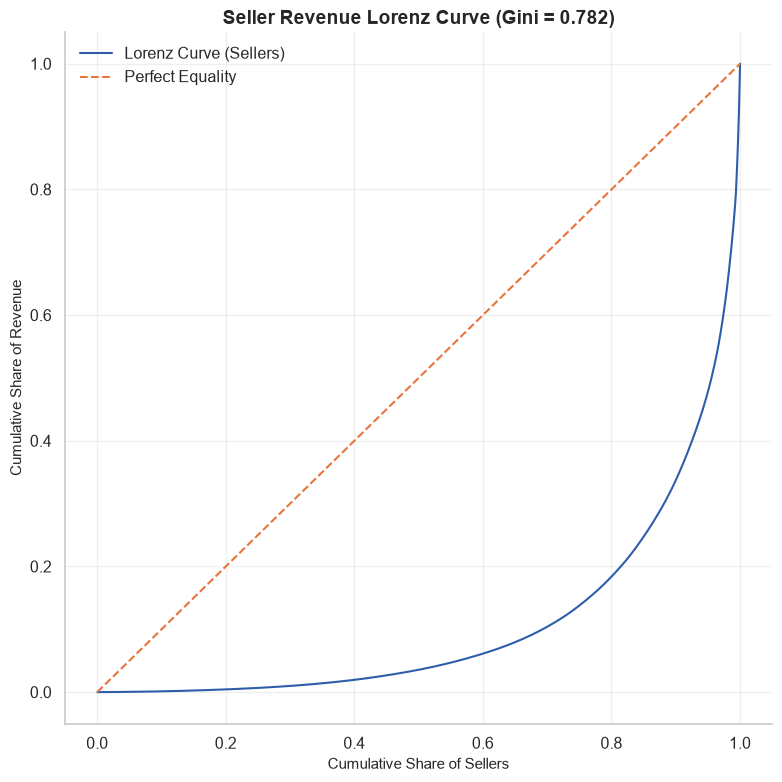


Sanity check vs. SQL finding: top 19% of active sellers (564 sellers) generate 80.51% of revenue


In [8]:
def gini_coefficient(values):
    values = np.sort(np.array(values))
    n = len(values)
    cumvals = np.cumsum(values)
    return (2 * np.sum(np.arange(1, n + 1) * values) - (n + 1) * cumvals[-1]) / (n * cumvals[-1])

gini_all = gini_coefficient(seller_performance['total_revenue'].values)

active_sellers = seller_performance[seller_performance['total_revenue'] > 0]
gini_active = gini_coefficient(active_sellers['total_revenue'].values)

print(f"Gini coefficient (all {len(seller_performance)} sellers, including zero-revenue): {gini_all:.4f}")
print(f"Gini coefficient ({len(active_sellers)} sellers with revenue > 0): {gini_active:.4f}")

sorted_revenue = np.sort(active_sellers['total_revenue'].values)
cum_revenue = np.cumsum(sorted_revenue) / sorted_revenue.sum()
cum_sellers = np.arange(1, len(sorted_revenue) + 1) / len(sorted_revenue)

fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(cum_sellers, cum_revenue, color=PALETTE[0], label='Lorenz Curve (Sellers)')
ax.plot([0, 1], [0, 1], color=PALETTE[1], linestyle='--', label='Perfect Equality')
ax.set_xlabel('Cumulative Share of Sellers')
ax.set_ylabel('Cumulative Share of Revenue')
ax.set_title(f'Seller Revenue Lorenz Curve (Gini = {gini_active:.3f})')
ax.legend()
plt.tight_layout()
plt.show()

top_19_pct_cutoff = int(len(active_sellers) * 0.19)
top_19_revenue_share = (
    active_sellers.nlargest(top_19_pct_cutoff, 'total_revenue')['total_revenue'].sum()
    / active_sellers['total_revenue'].sum() * 100
)
print(f"\nSanity check vs. SQL finding: top 19% of active sellers ({top_19_pct_cutoff} sellers) generate "
      f"{top_19_revenue_share:.2f}% of revenue")

**Finding:** Gini coefficient is 0.7908 across all 3,095 sellers (including zero-revenue) and 0.7820 among the 2,970 active sellers — both extremely high (0 = perfect equality, 1 = total inequality; a country's income Gini rarely exceeds 0.6). The Lorenz curve confirms this visually: the bottom ~60% of sellers collectively hold a near-flat, near-zero share of revenue, with essentially all of it concentrated in the top 10–20%. The sanity check reproduces SQL's Pareto finding almost exactly — the top 19% of active sellers (564 sellers) generate 80.51% of revenue, versus SQL's "19% drive 80%." Seller revenue concentration isn't just skewed, it's extreme by any standard economic benchmark, reinforcing that platform revenue health is a small-seller-base dependency risk, not a broad base of moderately-successful sellers.

## Assumptions & Limitations

- Clustering, outlier detection, and correlation analysis restricted to sellers with ≥5 orders (1,794 of 3,095) to match SQL's own scoring threshold — excludes most registered sellers, who are low-volume or never-active.
- The "quality z-score" used for outlier detection is an equal-weighted average of review, on-time, and (negated) cancellation z-scores — a simplification, not a validated weighting like SQL's composite score.
- Correlation and clustering show association, not causation — "quality doesn't predict revenue" describes this dataset's pattern, not a claim that quality is irrelevant to sellers generally.
- Gini coefficient differs slightly (0.7908 vs. 0.7820) depending on whether zero-revenue sellers are included — both tell a consistent story of extreme concentration.

Full detail in `docs/08_findings_python.md`.

## Summary

- Unsupervised clustering finds only 2 real seller quality groups (Elite vs. everyone else), not the four-tier structure SQL's manual scoring implies.
- Manual tiering understates revenue at risk by roughly 28× (0.22% vs. 6.2%) because the composite score's revenue weighting masks quality problems hiding inside the "Strong" tier.
- No seller combines high revenue with poor quality at a strict threshold — sellers with real quality problems generally don't scale — except one clear outlier (`b1b3948701c5c72445495bd161b83a4c`) worth flagging individually.
- Quality metrics move together as expected (review, on-time, cancellation all correlate), but none correlate with revenue — quality and scale are statistically independent on this platform.
- Seller revenue concentration is extreme (Gini ≈ 0.79; top 19% of sellers generate 80.5% of revenue) — platform revenue depends on a small core of sellers, not a broad base.